# Visual for percolation output

Parsing data from json files, and extracting metrics and configuration

In [71]:
import os
import matplotlib.pyplot as plt
import json
import numpy as np

PATH = "./"

def read_metrics(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def extract_metrics(data):
    config = data['config']
    metrics = data['metrics']
    return config, metrics

def calculate_probability_range(config, record_length):
    p0 = config['prob_from']
    p1 = config['prob_to']
    step = config['steps']
    maxv = 65535.0

    x_uint16 = list(range(p0, p1-step, step))
    print(len(x_uint16))
    x_percent = [(v / maxv) * 100 for v in x_uint16]

    return x_percent
    

The activation and span plotting functions

In [2]:
def plot_metrics(metrics, config):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    activation = metrics['activation']
    probability = calculate_probability_range(config, len(activation))

    # Plot Probability vs Mean Spanning
    ax1.plot(probability, metrics['spanning'], linestyle='-', color='b')
    ax1.set_title(f'Mean spanning for {config['simulation_number']} on {config['matrix_row']}x{config['matrix_col']} matrix')
    ax1.set_xlabel('Occupation probability %')
    ax1.set_ylabel('Mean Spanning')
    ax1.grid(True)

    # Plot Probability vs Mean Activation
    ax2.plot(probability, metrics['activation'], linestyle='-', color='r')
    ax2.set_title(f'Mean activation for {config['simulation_number']} on {config['matrix_row']}x{config['matrix_col']} matrix')
    ax2.set_xlabel('Occupation probability %')
    ax2.set_ylabel('Mean Activation')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('probability_analysis.png')
    
    #     plt.plot(x_range, spanning, color='red')
    # plt.grid(axis='both', color='0.8', linestyle=':')

    print("Plot saved as 'probability_analysis.png'")


In [3]:
# read up all files in the directory and plot the activation metric for each file
all_metrics = list()
def plot_all_activations(directory):
    for filename in os.listdir(directory):
        if filename.startswith("percolation_metrics") and filename.endswith(".json"):
            file_path = os.path.join(directory, filename)
            data = read_metrics(file_path)
            config, metrics = extract_metrics(data)
            all_metrics.append({'config': config, 'metrics': metrics})
            plot_metrics(metrics, config)



In [4]:
plot_all_activations(PATH)

In [5]:
#find metrics with 60x60 matrix 
metrics_60x60 = [metric for metric in all_metrics if metric['config']['matrix_row'] == 60 and metric['config']['matrix_col'] == 60] 

spanning_60 = metrics_60x60[0]['metrics']['spanning']
print(spanning_60)
# get index of spanning where it is bigger than 0.1 and smaller than 0.9
index_10 = next(i for i, v in enumerate(spanning_60) if v > 0.1)
index_90 = next(i for i, v in enumerate(spanning_60) if v > 0.9)
print(f"Index of spanning > 0.1: {index_10}, Index of spanning > 0.9: {index_90}")

# calculate probability at index 10 and 90
prob_from = metrics_60x60[0]['config']['prob_from']
prob_to = metrics_60x60[0]['config']['prob_to']
steps = metrics_60x60[0]['config']['steps']
uint16_max = 65535.0
range_val = prob_to - prob_from
uint16_value = lambda x: prob_from + (x / (steps - 1)) * range_val
to_percent = lambda x: (uint16_value(x) / uint16_max) * 100
prob_10_not_normalized = uint16_value(index_10)
prob_10 = to_percent(index_10)
prob_90_not_normalized = uint16_value(index_90)
prob_90 = to_percent(index_90)
print(f"Probability at index 10: {prob_10_not_normalized/range_val*uint16_max} {prob_10}%, Probability at index 90: {prob_90_not_normalized/range_val*uint16_max} {prob_90}%")

activation_60 = metrics_60x60[0]['metrics']['activation']
activation_at_10 = activation_60[index_10]
activation_at_90 = activation_60[index_90]
print(f"Activation at index 10: {activation_at_10}, Activation at index 90: {activation_at_90}")


IndexError: list index out of range

In [ ]:
#find metrics with 60x60 matrix 
metrics_30 = [metric for metric in all_metrics if metric['config']['matrix_row'] == 30 and metric['config']['matrix_col'] == 30] 

spanning_30 = metrics_30[0]['metrics']['spanning']
print(spanning_30)
# get index of spanning where it is bigger than 0.1 and smaller than 0.9
index_10 = next(i for i, v in enumerate(spanning_30) if v > 0.1)
index_90 = next(i for i, v in enumerate(spanning_30) if v > 0.9)
index_50 = next(i for i, v in enumerate(spanning_30) if v > 0.5)
index_60 = next(i for i, v in enumerate(spanning_30) if v > 0.65)
prob_range = calculate_probability_range(metrics_30[0]["config"], len(metrics_30[0]["metrics"]['spanning']))
print(f"Index of spanning > 0.1: {index_10}, Index of spanning > 0.9: {index_90}")
print(f"Index of spanning > 0.5: {index_50}, Index of spanning > 0.6: {index_60}")



idx_10_at60_of_30 = spanning_30[index_10]
idx_90_at60_of_30 = spanning_30[index_90]
print(f"Probability of spanning for 10% of 60x60 matrix: {spanning_60[index_10]}, same index for 30x30 {idx_10_at60_of_30},")
print(f"Probability of spanning for 90% of 60x60 matrix: {spanning_60[index_90]}, same index for 30x30 {idx_90_at60_of_30}")

# calculate probability at index 10 and 90
prob_10_not_normalized = uint16_value(index_10)
prob_10 = to_percent(index_10)
prob_90_not_normalized = uint16_value(index_90)
prob_90 = to_percent(index_90)
print(f"Probability at index 10: {prob_10_not_normalized/range_val*uint16_max} {prob_10}%, Probability at index 90: {prob_90_not_normalized/range_val*uint16_max} {prob_90}%")

activation_30 = metrics_30[0]['metrics']['activation']
activation_at_10 = activation_30[index_10]
activation_at_90 = activation_30[index_90]
print(f"Activation at index 10: {activation_at_10}, Activation at index 90: {activation_at_90}")


In [ ]:
import numpy as np
from scipy.interpolate import interp1d

# make sure arrays
x = np.array(prob_range)
y = np.array(spanning_60)

# sort (important if not already sorted)
idx = np.argsort(x)
x, y = x[idx], y[idx]

# interpolate inverse: y -> x
f_inv = interp1d(y, x)

x_at_05 = f_inv(0.5)
print(x_at_05)

# Read up metrics from uncorrelated h5

In [6]:
import h5py


def first_mf():
    metrics = dict()
    with h5py.File("metrics_30x30_1000.h5", "r") as f:
        prob       = f["probability"][:]   # (n_metrics,)
        activation = f["activation"][:]    # (n_metrics,)
        spanning   = f["spanning"][:]      # (n_metrics, n_steps)
        evolution  = f["evolution"][:]     # (n_metrics, n_steps, rows*cols)
        metrics = {
            'probability': prob,
            'activation': activation,
            'spanning': spanning,
            'evolution': evolution
        }
    return metrics

In [7]:
metrics = first_mf()
print(metrics['probability'].shape)
print(metrics['activation'].shape)
print(metrics['spanning'].shape)
print(metrics['evolution'].shape)


(1700,)
(1700,)
(1700, 1000)
(1700, 1000, 900)


In [8]:
def compute_energies_uncorr(evolutions):
    s = (2 * evolutions - 1).reshape(-1, 30, 30)  # (1000, 30, 30), ±1

    right = np.roll(s, -1, axis=2)                # right neighbors
    down  = np.roll(s, -1, axis=1)                # down neighbors

    return -np.sum(s * right, axis=(1,2)) \
           -np.sum(s * down,  axis=(1,2))          # (1000,) energies

In [9]:
evolutions_uncorr = metrics["evolution"][8]
energies = compute_energies_uncorr(evolutions_uncorr)      # (1000,)

# only 1000 points → direct method fine, no need for FFT
def uncorrelated_autocorrelation(E):
    E = E - E.mean()
    corr = np.correlate(E, E, mode='full')
    corr = corr[len(corr)//2:]
    corr /= corr[0]
    return corr

uncorr_corr = uncorrelated_autocorrelation(energies)

In [10]:
print(metrics["probability"][8])
print(metrics["evolution"][8])

59.375908
[[1 0 1 ... 1 0 0]
 [1 0 1 ... 1 0 0]
 [1 0 1 ... 1 0 0]
 ...
 [1 1 0 ... 1 1 1]
 [1 1 0 ... 1 1 1]
 [1 1 0 ... 1 1 1]]


In [11]:
import cv2
import numpy as np

def generate_video_from_flat_vectors(data_sequence, output_filename='output.mp4', fps=10, scale_factor=20):
    print(data_sequence.shape)
    height, width = 30, 30
    scaled_dims = (width * scale_factor, height * scale_factor)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_filename, fourcc, fps, scaled_dims, isColor=False)
    
    for flat_frame in data_sequence:
        arr = np.array(flat_frame, dtype=np.uint8)
        arr = np.array(flat_frame, dtype=np.uint8)
        matrix = arr.reshape(30, 30)
        frame = matrix * 255
        scaled_frame = cv2.resize(frame, scaled_dims, interpolation=cv2.INTER_NEAREST)
        
        out.write(scaled_frame)
        
    out.release()
    print(f"Video saved as {output_filename}")

# generate_video_from_flat_vectors(metrics['evolution'][0], "uncorr_1000_30x30.mp4", 30)

In [21]:
import matplotlib.pyplot as plt
def plot_uncorr_data(mean_data):
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(mean_data['probability'], mean_data['spanning'], marker='o', linestyle='-', color='b')
    ax.set_title('Probability vs Mean Spanning')
    ax.set_xlabel('Probability')
    ax.set_ylabel('Mean Spanning')
    ax.grid(True)

    plt.tight_layout()
    plt.savefig('probability_analysis.png')
    print("Plot saved as 'probability_analysis.png'")

In [13]:
import pandas as pd

probability = np.array(metrics['probability']).flatten()
activation = np.array(metrics['activation']).flatten()
spanning_array = np.array(metrics['spanning'])
spanning_summed = spanning_array.sum(axis=1) / spanning_array.shape[1]
print(spanning_array.shape[1])
print(probability.shape)
print(activation.shape)
print(spanning_summed.shape)


data = pd.DataFrame({
    'probability': probability,
    'activation': activation,
    'spanning': spanning_summed
})

1000
(1700,)
(1700,)
(1700,)


Plot saved as 'probability_analysis.png'


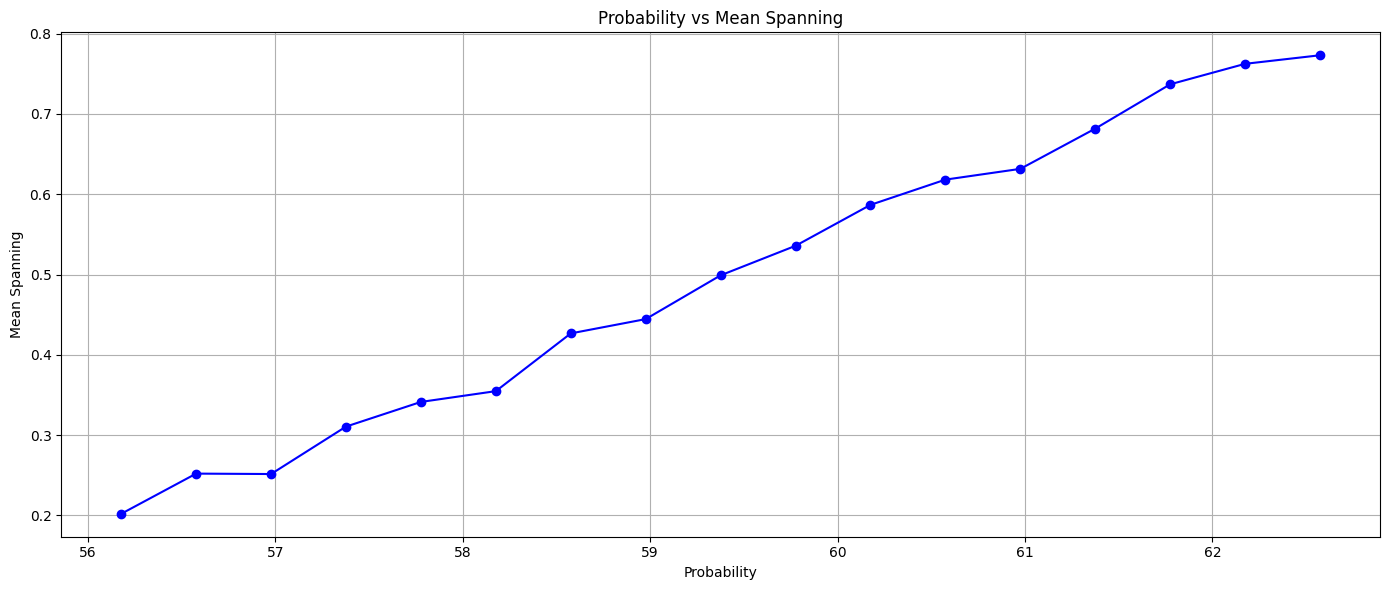

In [22]:
mean_data = data.groupby('probability').mean().reset_index()
plot_uncorr_data(mean_data)

# Spanning fluctuation for every probability

In [23]:
def plot_spanning_with_fluctuation(stats):
    plt.figure(figsize=(10, 6))

    # Line for mean
    plt.plot(stats['probability'], stats['mean'], color='red', label='Mean')

    # Shadow for fluctuation
    plt.fill_between(stats['probability'], 
                    stats['mean'] - stats['std'], 
                    stats['mean'] + stats['std'], 
                    color='red', alpha=0.2, label='Fluctuation (Std)')

    plt.xlabel('Probability')
    plt.ylabel('Spanning')
    plt.title('Spanning with Fluctuation')
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.show()

In [24]:
# Group data by probability and aggregate mean and standard deviation
stats = data.groupby('probability')['spanning'].agg(['mean', 'std']).reset_index()

print(stats.to_string())


    probability     mean       std
0     56.177616  0.20207  0.161560
1     56.577404  0.25210  0.159298
2     56.977188  0.25158  0.168493
3     57.376976  0.31064  0.184154
4     57.776760  0.34136  0.199013
5     58.176548  0.35479  0.214267
6     58.576332  0.42668  0.191082
7     58.976120  0.44448  0.204534
8     59.375908  0.49899  0.202749
9     59.775692  0.53576  0.203827
10    60.175480  0.58671  0.186877
11    60.575264  0.61814  0.185103
12    60.975052  0.63155  0.212908
13    61.374836  0.68167  0.187487
14    61.774624  0.73684  0.171772
15    62.174408  0.76234  0.174229
16    62.574196  0.77299  0.158606


In [ ]:
# plot_spanning_with_fluctuation(stats)

# Handling ising model

In [25]:
ising_metrics = dict()

with h5py.File("ising_metrics_30x30_100000_05.h5", "r") as f:
    prob       = f["probability"][:]   # (n_metrics,)
    initial_activation = f["initial_activation"][:]    # (n_metrics,)
    initial_energy = f["initial_energy"][:] # (n_metrics,)
    spanning   = f["spanning"][:]      # (n_metrics, n_steps)
    evolution  = f["evolution"][:]     # (n_metrics, n_steps, rows*cols)
    acceptance = f["acceptance"][:] # (n_metrics, n_steps)
    net_energy = f["net_energy"][:] # (n_metrics, n_steps)
    ising_metrics = {
        'probability': prob,
        'initial_activation': initial_activation,
        'initial_energy': initial_energy,
        'spanning': spanning,
        'evolution': evolution,
        'acceptance': acceptance,
        'net_energy': net_energy,
    }

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'ising_metrics_30x30_100000_05.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
print(ising_metrics["probability"])
print(ising_metrics["evolution"].shape)
print(ising_metrics["evolution"].dtype)
# portion = ising_metrics['evolution'][0][0]
# portion = portion.reshape(30,30)
# print(portion)
# generate_video_from_flat_vectors(ising_metrics['evolution'][0], "ising_out.mp4", 30)

In [ ]:

ising_probability = np.array(ising_metrics['probability']).flatten()
ising_activation = np.array(ising_metrics['activation'])
ising_activation_summed = ising_activation.sum(axis=1) / ising_activation.shape[1]
ising_spanning_array = np.array(ising_metrics['spanning'])
ising_spanning_summed = spanning_array.sum(axis=1)
ising_spanning = ising_spanning_array.sum(axis=1) / ising_spanning_array.shape[1]
ising_energy_array = np.array(ising_metrics['net_energy'])
ising_energy_summed = ising_energy_array.sum(axis=1) / ising_energy_array.shape[1]

print(ising_probability.shape)
print(ising_activation.shape)
print(ising_spanning_summed.shape)
# print(ising_energy_array.shape)
# en_144 = [x for x in ising_energy_array if ising_energy_array[0] == 144]
# print(en_144)
ising_data = pd.DataFrame({
    'probability': ising_probability,
    'activation': ising_activation_summed,
    'spanning': ising_spanning,
})

In [ ]:
ising_mean_data = ising_data.groupby('probability').mean().reset_index()
plot_uncorr_data(ising_mean_data)

In [ ]:

ising_stats = ising_data.groupby('probability')['spanning'].agg(['mean', 'std']).reset_index()

print(ising_stats.to_string())
# plot_spanning_with_fluctuation(ising_stats)

In [26]:
def plot_spanning_data(data1, data2):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Probability vs Mean Spanning
    ax1.plot(data1['probability'], data1['spanning'], label='uncor', linestyle='-', color='b')
    ax1.plot(data2['probability'], data2['spanning'], label='ising', linestyle='-', color='r')
    ax1.set_title('Probability vs Mean Spanning')
    ax1.set_xlabel('Probability')
    ax1.set_ylabel('Mean Spanning')
    ax1.grid(True)

    # Plot Probability vs Mean Activation
    ax2.plot(data1['probability'], data1['activation'], label='uncor', linestyle='-', color='b')
    ax2.plot(data2['probability'], data2['activation'], label='ising', linestyle='-', color='r')
    ax2.set_title('Probability vs Mean Activation')
    ax2.set_xlabel('Probability')
    ax2.set_ylabel('Mean Activation')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('probability_analysis_uncorr_ising.png')
    print("Plot saved as 'probability_analysis_uncorr_ising.png'")





In [ ]:
plot_spanning_data(mean_data, ising_mean_data)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(ising_energy_array[0], label='en', linestyle='-', color='r')
ax1.set_title('One case energy')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Energy')
ax1.grid(True)

ax1.plot(ising_energy_array[99], label='en', linestyle='-', color='b')
ax1.set_title('One case energy')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Energy')
ax1.grid(True)

plt.tight_layout()

# Ising model with Kawasaki dynamics

In [51]:
import h5py

def load_metrics_ising(file, has_evolution):
    metrics = dict()

    with h5py.File(file, "r") as f:
        prob       = f["probability"][:]   # (n_metrics,)
        initial_activation = f["initial_activation"][:]    # (n_metrics,)
        initial_energy = f["initial_energy"][:] # (n_metrics,)
        spanning   = f["spanning"][:]      # (n_metrics, n_steps)
        beta = f["beta"][:]
        net_energy = f["net_energy"][:] # (n_metrics, n_steps)
        acceptance = f["acceptance"][:]
        correlation = f["correlation"][:]
        metrics = {
            'probability': prob,
            'initial_activation': initial_activation,
            'initial_energy': initial_energy,
            'spanning': spanning,
            'net_energy': net_energy,
            'correlation': correlation,
            'acceptance': acceptance,
            'beta': beta,
        }
        if has_evolution :
            evolution  = f["evolution"][:]     # (n_metrics, n_steps, rows*cols)
            metrics["evolution"] = evolution
    return metrics

In [28]:
def organize_to_data_frame(metrics):
    probability = np.array(metrics['probability']).flatten()
    spanning_array = np.array(metrics['spanning'])
    spanning = spanning_array.sum(axis=1) / spanning_array.shape[1]
    energy_array = np.array(metrics['net_energy'])
    acc_array = np.array(metrics['acceptance'])
    energy_summed = energy_array.sum(axis=1) / energy_array.shape[1]

    print(probability.shape)

    data = {
        'probability': probability,
        'spanning': spanning,
        'energy_array' : energy_array,
        'energy_summed': energy_summed,
        'acceptance': acc_array
    }
    return data

def plot_energy_acceptance(data, index, title_info=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.plot(data["energy_array"][index], label='en', linestyle='-', color='r')
    ax1.set_title(f'Potential energy over steps {title_info} with prob {data['probability'][index]:.2f}')
    ax1.set_xlabel('\'t\' Steps')
    ax1.set_ylabel('Potential Energy')
    ax1.grid(True)
    cummulative_acceptance = np.cumsum(data["acceptance"][index])
    ax2.plot(cummulative_acceptance, label='en', linestyle='-', color='b')
    ax2.set_title(f'Cumulative acceptance {title_info} with prob {data['probability'][index]:.2f}')
    ax2.set_xlabel('\'t\' Steps')
    ax2.set_ylabel('Cumulative Acceptance')
    ax2.grid(True)

    plt.tight_layout()
    
def plot_spanning_ising(data, index, title_info=''):
    spanning = np.array(data["spanning"][index], dtype=float)
    window = 10000  # adjust based on your data size
    moving_avg = np.convolve(spanning, np.ones(window)/window, mode='valid')
    plt.figure(figsize=(10, 6))
    plt.plot(moving_avg, label='spanning', linestyle='-', color='g')
    plt.title(f'Spanning over steps {title_info} with prob {data['probability'][index]:.2f}')
    plt.xlabel('\'t\' Steps')
    plt.ylabel('Spanning')
    plt.grid(True)
    plt.show()


In [29]:
def draw_indicator(frame, condition, center=(15, 15), radius=10):
    if condition:
        cv2.circle(
            frame,
            center=center,
            radius=radius,
            color=(0, 0, 255),  # red (BGR)
            thickness=-1
        )
    return frame

def generate_video_from_flat_vectors_span(data_sequence, spanning, output_filename='output.mp4', fps=10, scale_factor=20):
    print(data_sequence.shape)

    height, width = 30, 30
    scaled_dims = (width * scale_factor, height * scale_factor)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_filename, fourcc, fps, scaled_dims, isColor=True)
    for i, flat_frame in enumerate(data_sequence):
        matrix = np.array(flat_frame, dtype=np.uint8).reshape(30, 30)

        color_frame = np.zeros((30, 30, 3), dtype=np.uint8)
        color_frame[..., 1] = matrix * 255   # green channel

        scaled_frame = cv2.resize(color_frame, scaled_dims, interpolation=cv2.INTER_NEAREST)

        scaled_frame = draw_indicator(scaled_frame, spanning[i])

        out.write(scaled_frame)
        
    out.release()
    print(f"Video saved as {output_filename}")

In [ ]:
# generate_video_from_flat_vectors_span(ising_metrics_sub['evolution'][0], ising_metrics_sub['spanning'][0], "ising_out_sub_col_05.mp4", 60)

# Ising on different betas

In [30]:
# read up metrics into a list
def ising_metrics_for_different_beta(directory):
    metrics = []
    for filename in os.listdir(directory):
        if filename.startswith("ising_metrics") and filename.endswith(".h5"):
            file_path = os.path.join(directory, filename)
            data = load_metrics_ising(file_path, False)
            metrics.append(data)
    return metrics

In [33]:
betas_path = PATH + "/different_beta"
betas_metrics = ising_metrics_for_different_beta(betas_path)
# order by beta
betas_metrics.sort(key=lambda x: x['beta'][0])

In [34]:
# print(len(betas_metrics))

def plot_energy_vs_beta_and_energy_vs_time(metrics_list, title_info=''):
    avg_energies = []
    betas = []
    
    for i, metrics in enumerate(metrics_list):
        energy_array = np.array(metrics['net_energy']) # (n_metrics, n_steps)
        avg_energy = energy_array[:, -10000:].mean()  # Average of last 10,000 steps
        avg_energies.append(avg_energy)
        betas.append(1/metrics['beta'][0])  # Assuming beta is the same for all metrics in the file
        
    print(betas)
    print(avg_energies)
    # create plot for the 2 data:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.plot(betas, avg_energies, marker='o', linestyle='-', color='m')
    for i, (xi, yi) in enumerate(zip(betas, avg_energies)):
        ax1.annotate(f"{yi:.2f}",
                 (xi, yi),
                 textcoords="offset points",
                 xytext=(0, 15 if i % 2 == 0 else -15),
                 ha='center',
                 arrowprops=dict(arrowstyle='-'))
    ax1.set_title(f'Average Energy vs Temperature {title_info}')
    ax1.set_xlabel('Temperature (1/beta)')
    ax1.set_ylabel('Average Energy (Last 10,000 steps)')
    ax1.grid(True)
    # save ax1 separately
    ax1.figure.savefig(f'energy_vs_temperature{title_info}.png')
    print("Plot saved as 'energy_vs_temperature.png'")

    
    # plot energy evolution for all betas
    for i, metrics in enumerate(metrics_list):
        # take last 10,000 steps
        ax2.plot(metrics['net_energy'][0][-10000:], label=f'Beta = {metrics["beta"][0]:.2f}')
    ax2.set_title(f'Energy Evolution vs Time {title_info}')
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Energy')
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax2.grid(True)
    ax2.figure.savefig(f'energy_vs_time_{title_info}.png')
    print("Plot saved as 'energy_vs_time.png'")
    



0.05
[np.float32(20.0), np.float32(10.0), np.float32(5.0), np.float32(3.3333333), np.float32(2.5), np.float32(2.0), np.float32(1.6666666), np.float32(1.0), np.float32(0.1), np.float32(0.01)]
[np.float64(-151.266), np.float64(-229.6056), np.float64(-425.78253333333333), np.float64(-672.9186666666667), np.float64(-944.5849333333333), np.float64(-1293.3888), np.float64(-1457.5938666666666), np.float64(-1571.0913333333333), np.float64(-1569.1672), np.float64(-1567.1426666666666)]
Plot saved as 'energy_vs_temperature.png'
Plot saved as 'energy_vs_time.png'


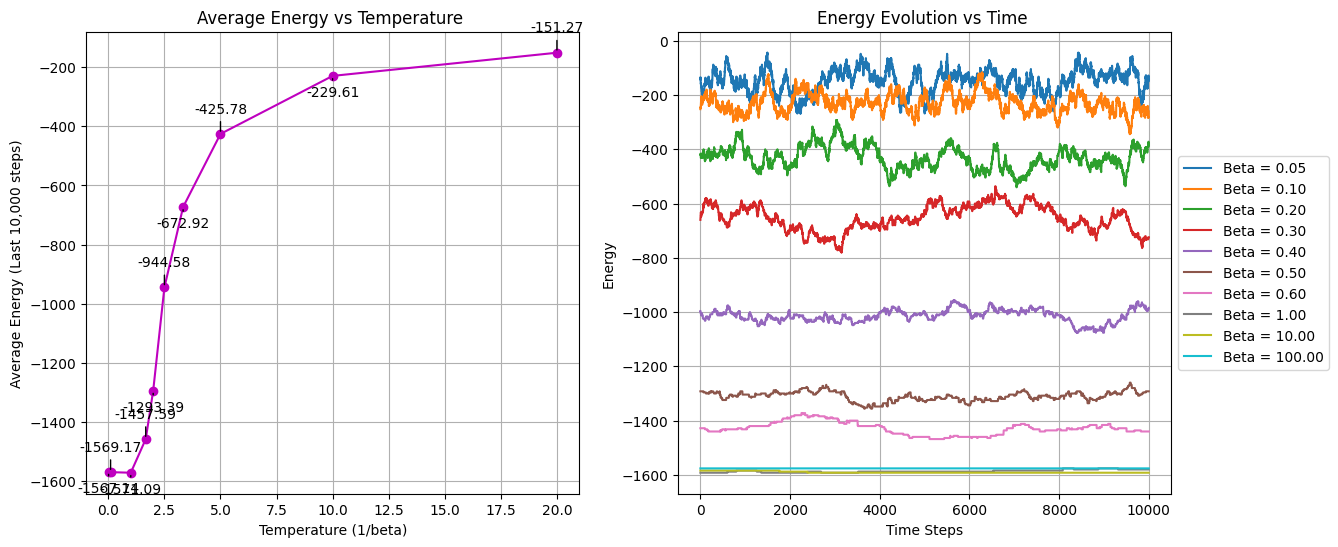

In [35]:
print(betas_metrics[0]["beta"][0])
plot_energy_vs_beta_and_energy_vs_time(betas_metrics)

In [36]:
ising_metrics_01 = load_metrics_ising("ising_metrics_30x30_100000_evol0.100000.h5", True)
# generate_video_from_flat_vectors_span(ising_metrics_01['evolution'][0], ising_metrics_01['spanning'][0], "ising_out_sub_col_01.mp4", 100)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'ising_metrics_30x30_100000_evol0.100000.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

# Simulation on 60 x 60 matrics, for different betas

0.01
[np.float32(100.0), np.float32(10.0), np.float32(5.0), np.float32(3.3333333), np.float32(2.5), np.float32(2.0), np.float32(1.6666666), np.float32(1.0), np.float32(0.6666667), np.float32(0.5), np.float32(0.45454544), np.float32(0.4), np.float32(0.37037036), np.float32(0.33333334), np.float32(0.3030303), np.float32(0.25), np.float32(0.2), np.float32(0.14285715), np.float32(0.1), np.float32(0.05)]
[np.float64(-364.3968), np.float64(-950.9776), np.float64(-1721.1352), np.float64(-2702.8556), np.float64(-3937.8772), np.float64(-5092.8836), np.float64(-5489.9856), np.float64(-5919.5452), np.float64(-5960.2144), np.float64(-5875.3584), np.float64(-5921.304), np.float64(-5913.71), np.float64(-5889.8284), np.float64(-5894.1904), np.float64(-6021.1392), np.float64(-5795.7824), np.float64(-5914.7664), np.float64(-5838.4704), np.float64(-5919.3564), np.float64(-5873.026)]
Plot saved as 'energy_vs_temperature.png'
Plot saved as 'energy_vs_time.png'


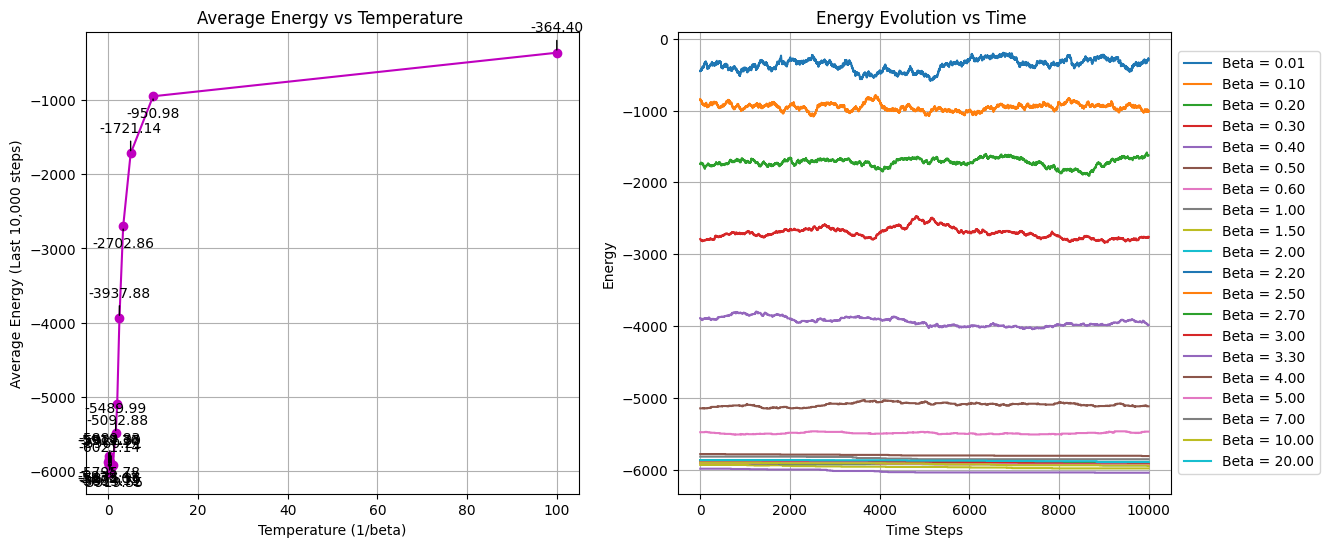

In [37]:
betas_60_path = PATH + "/different_beta_60"
betas_metrics_60 = ising_metrics_for_different_beta(betas_60_path)
# order by beta
betas_metrics_60.sort(key=lambda x: x['beta'][0])
print(betas_metrics_60[0]["beta"][0])
plot_energy_vs_beta_and_energy_vs_time(betas_metrics_60)


# 0.1 betas 3030

In [38]:
ising_metrics_01d = load_metrics_ising("ising_metrics_30x30_100000_d_0.100000.h5", True)
ising_data_01_d = organize_to_data_frame(ising_metrics_01d)
plot_energy_acceptance(ising_data_01_d, 0, 'at 0.1 beta')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'ising_metrics_30x30_100000_d_0.100000.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
generate_video_from_flat_vectors_span(ising_metrics_01d['evolution'][0], ising_metrics_01d['spanning'][0], "ising_total_energy_01.mp4", 100)

# Ising 30x30 matrix 10 million iteration 0.01 beta

In [39]:
ising_metrics_001 = load_metrics_ising("ising_metrics/ising_metrics_30_10000000_0.010000.h5", True)


(1,)


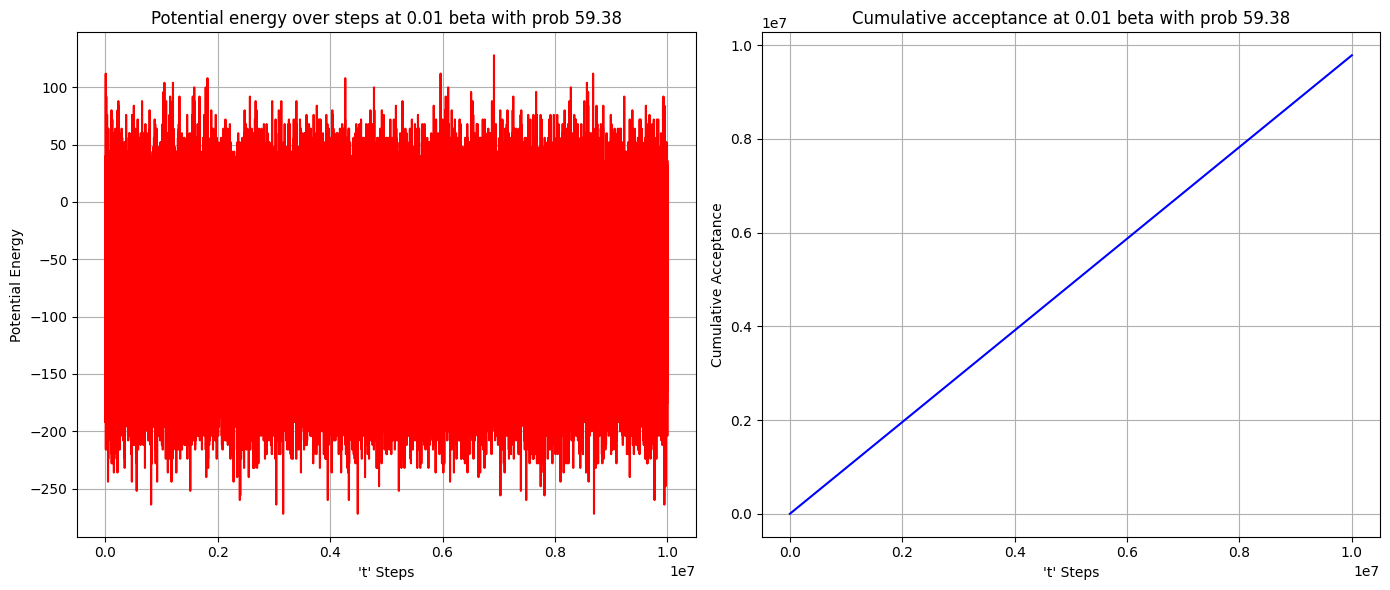

In [40]:
ising_data_001 = organize_to_data_frame(ising_metrics_001)
plot_energy_acceptance(ising_data_001, 0, 'at 0.01 beta')

[[1 1 1 ... 0 0 0]]


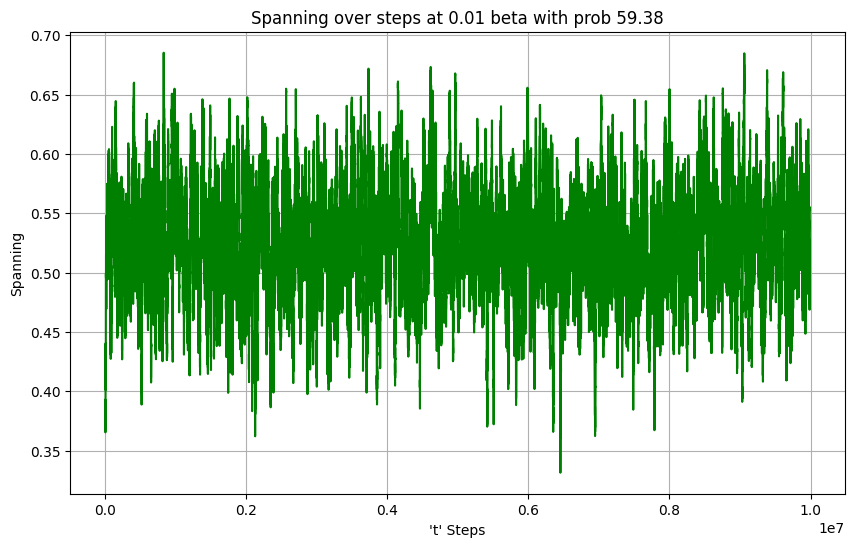

In [41]:
print(ising_metrics_001["spanning"])
plot_spanning_ising(ising_metrics_001, 0, 'at 0.01 beta')

In [ ]:
# generate_video_from_flat_vectors_span(ising_metrics_001['evolution'][0], ising_metrics_001['spanning'][0], "ising_total_energy_001_10mil.mp4", 5)

# Ising  30 x 30, 10 mill run, 2.2 beta

In [42]:
ising_metrics_22 = load_metrics_ising("ising_metrics/ising_metrics_30_10000000_2.200000.h5", True)


(1,)


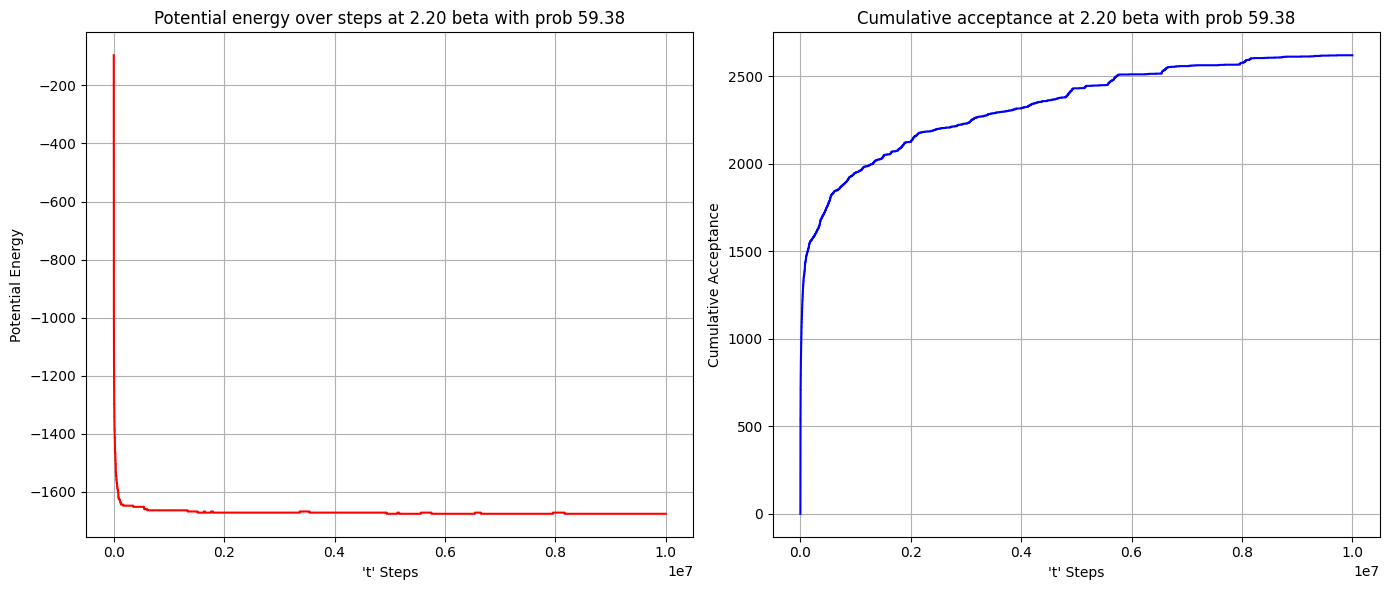

In [43]:
ising_data_22 = organize_to_data_frame(ising_metrics_22)
plot_energy_acceptance(ising_data_22, 0, 'at 2.20 beta')

[[1 1 1 ... 1 1 1]]


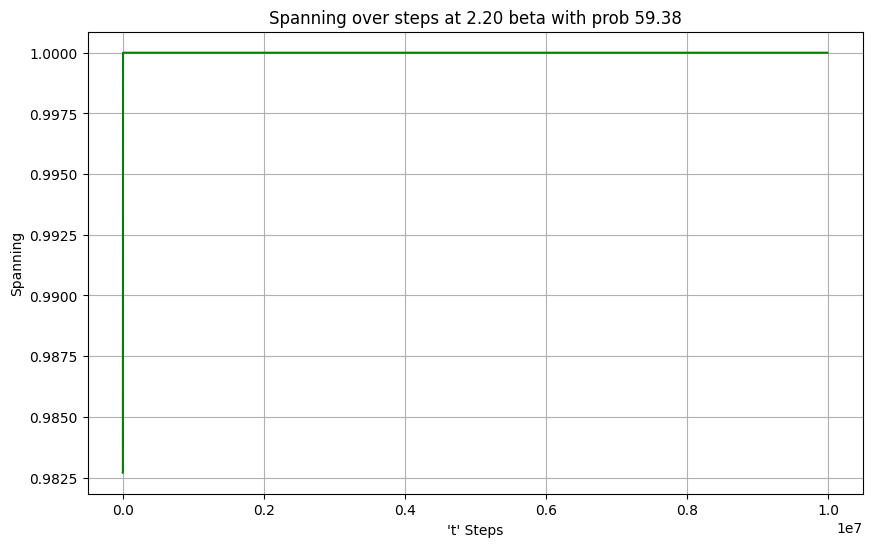

In [44]:
print(ising_metrics_22["spanning"])
plot_spanning_ising(ising_metrics_22, 0, 'at 2.20 beta')

In [ ]:
# generate_video_from_flat_vectors_span(ising_metrics_22['evolution'][0], ising_metrics_22['spanning'][0], "ising_total_energy_22_10mil.mp4", 5)

spanning probability as function of beta, 
calculate correlations for every temperature part
Took only 4 temp
c_ij = avg(n_i n_j) - 0.59*0.59 (p^2) assume i and j nearest neighbors
if i = j -> C_ii = p - p^2 = p(1-p)
if i not= j C_ij = <n_i*n_j> - p^2 = <n_i><n_j> - p*2 = 0
C_ij^hat = <ni*nj> - p^2/ (p-p^2)  if 1 -> correlate, if 0 uncorrelated

C_ij^hat(nearestneg) 
C_ij^hat (beta) plot in correspond to beta
plot spanning probability as a function of the correlation
for one part: 1/2N sum(n_i*n_i+1 + n_i*n_i+L) = <n_i*n_j>

Energy
<energy> = -2N<n_i*n_j>
<n_i*n_j> = <E>/2N
E = -Sum(si*sj) = - Sum(2n_i - 1 * 2n_j - 1) = - sum( 4 <n_i*n_j> - 4p + 1 )

# Ising correlation calculated from energy

In [45]:
def autocorrelation(E):
    E = np.asarray(E, dtype=np.float64).ravel()  # force 1D
    E_shifted = E - E.mean()
    
    n     = len(E_shifted)
    fft   = np.fft.rfft(E_shifted, n=2*n)        # zero-pad to avoid wrap-around
    power = fft * np.conj(fft)
    corr  = np.fft.irfft(power)[:n]              # keep τ >= 0
    corr /= corr[0]                              # normalize
    return corr

def calculate_correlation(E, tau_range):
    N = len(E)
    E_shifted = E - E.mean()          # will reach 0 if constant E is reduced
    correlation = np.zeros(tau_range)

    for tau in range(tau_range):
        accumulated = np.sum(E_shifted[:N-tau] * E_shifted[tau:])
        correlation[tau] = accumulated / (N - tau)
    
    correlation /= correlation[0]     # normalize by C(0)=1
    return correlation

def plot_correlation(correlation):
    timesteps = np.arange(len(correlation)) 
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(timesteps, correlation, label=f'Trajectory')  # normalized with C(0)
    plt.xscale('log')
    ax.set_xlabel('τ (log scale)')
    ax.set_ylabel('C(τ)')
    ax.set_title('Velocity Autocorrelation Function')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

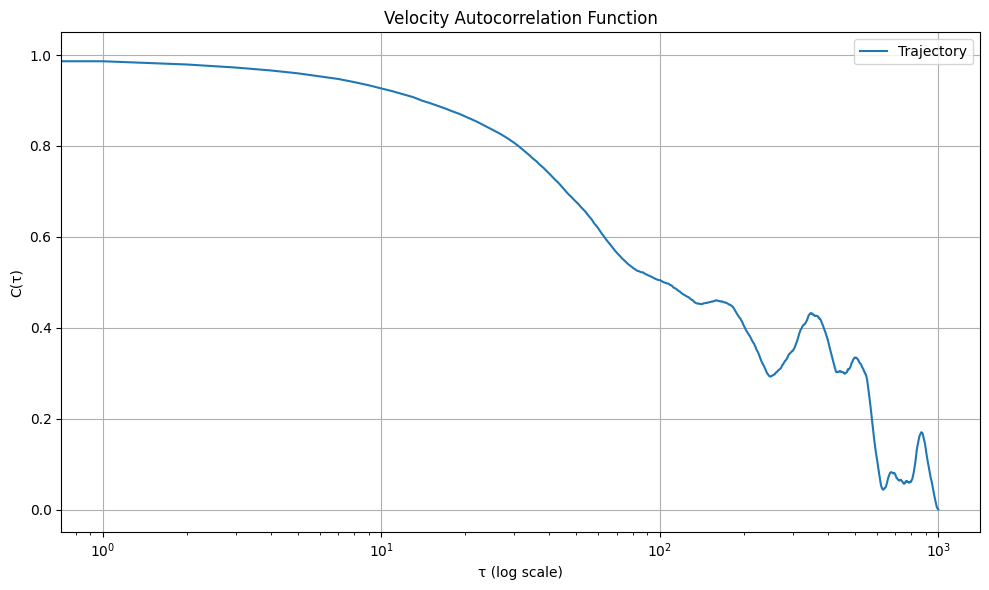

In [46]:
plot_correlation(uncorr_corr)

In [47]:
E = np.array(ising_metrics_22["net_energy"][0])
burnin = len(E) // 10        # drop first 10%
E      = E[burnin:]          # ~9M points remain
corr = autocorrelation(E)
print(len(corr))


9000000


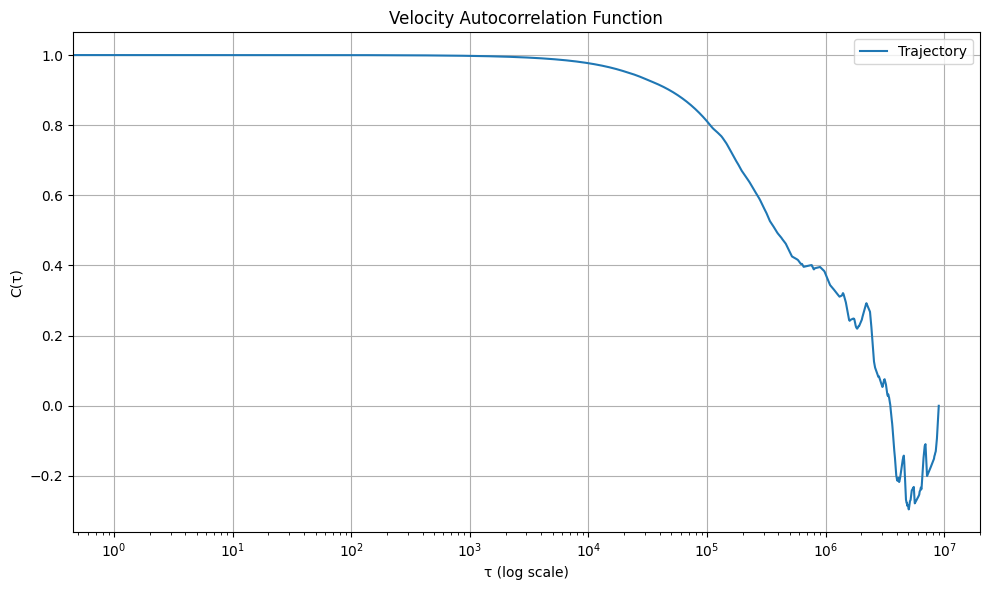

In [48]:
plot_correlation(corr)

In [49]:
E = np.array(ising_metrics_001["net_energy"][0])
burnin = len(E) // 10        # drop first 10%
E      = E[burnin:]          # ~9M points remain
corr = autocorrelation(E)
print(len(corr))

9000000


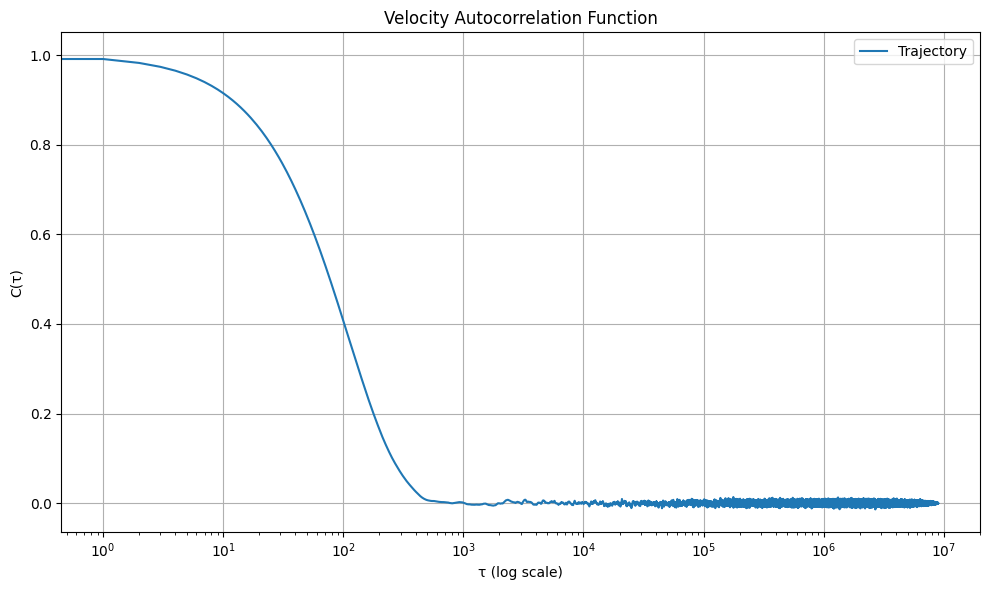

In [50]:
plot_correlation(corr)

# Correlation for Moving beta

In [72]:
ising_metrics_moving = load_metrics_ising("ising_metrics/ising_metrics_30_1000000_0.1_moving.h5", True)


(1,)
4


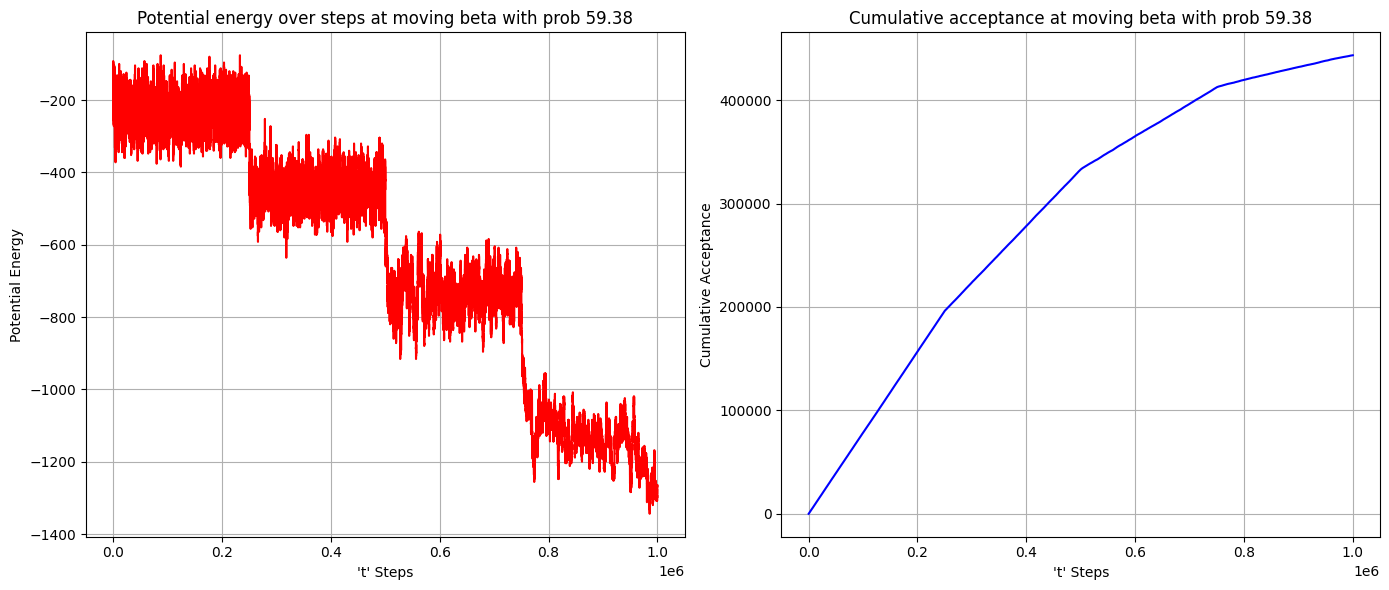

In [73]:
ising_data_moving = organize_to_data_frame(ising_metrics_moving)
print(len(set(ising_metrics_moving["beta"][0])))
plot_energy_acceptance(ising_data_moving, 0, 'at moving beta')

In [54]:
def plot_energy_acceptance_multiple_beta(data, index, title_info=''):
    fig, axs = plt.subplots(2, 2, figsize=(14, 6))
    
    beta_raw = data["beta"][index]
    energy_raw = data["net_energy"][index]
    betas = sorted(set(beta_raw))
    betas_index = sorted([int(np.where(beta_raw == b)[0][-1]) for b in betas])
    
    splits = [0] + betas_index[:-1]
    
    energies = [energy_raw[split:idx:1000] for split, idx in zip(splits, betas_index)]
    energies.append(energy_raw[betas_index[-1]::1000])

    for ax, energy, beta in zip(axs.flat, energies, betas):
        ax.plot(energy, linestyle='-', color='r')
        ax.set_title(f'Potential energy at {beta:.2f} with prob {data["probability"][index]:.2f}')
        ax.set_xlabel("'t' Steps")
        ax.set_ylabel('Potential Energy')
        ax.grid(True)

    plt.tight_layout()

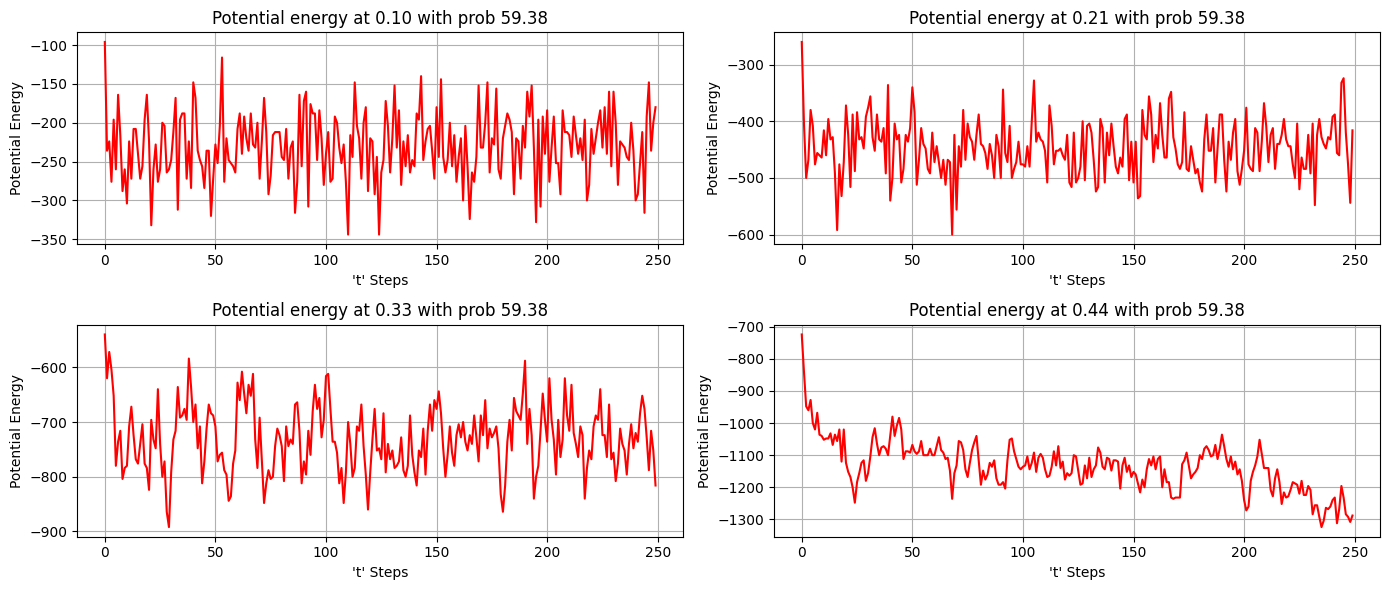

In [55]:
ising_metrics_moving["beta"][0]
plot_energy_acceptance_multiple_beta(ising_metrics_moving, 0, 'at moving beta')

In [56]:
ising_metrics_moving["correlation"][0]

array([0.01931358, 0.01931358, 0.01931358, ..., 0.6704247 , 0.6704247 ,
       0.6704247 ], shape=(1000000,), dtype=float32)

In [ ]:
# generate_video_from_flat_vectors_span(ising_metrics_moving['evolution'][0], ising_metrics_moving['spanning'][0], "ising_30_moving_beta.mp4", 5)

In [57]:
def plot_all_stages(correlations, betas):
    stages = np.array_split(correlations, 4)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    for ax, stage, beta in zip(axes.flat, stages, betas):
        corr = autocorrelation(stage)
        # find τ where corr drops to 1/e
        ax.plot(corr[:100000])
        ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.set_title(f'β={beta:.4f}, T={1/beta:.3f}')
        ax.set_xlabel('Sweep lag')
        ax.set_ylabel('Autocorrelation')
    
    plt.tight_layout()
    plt.show()

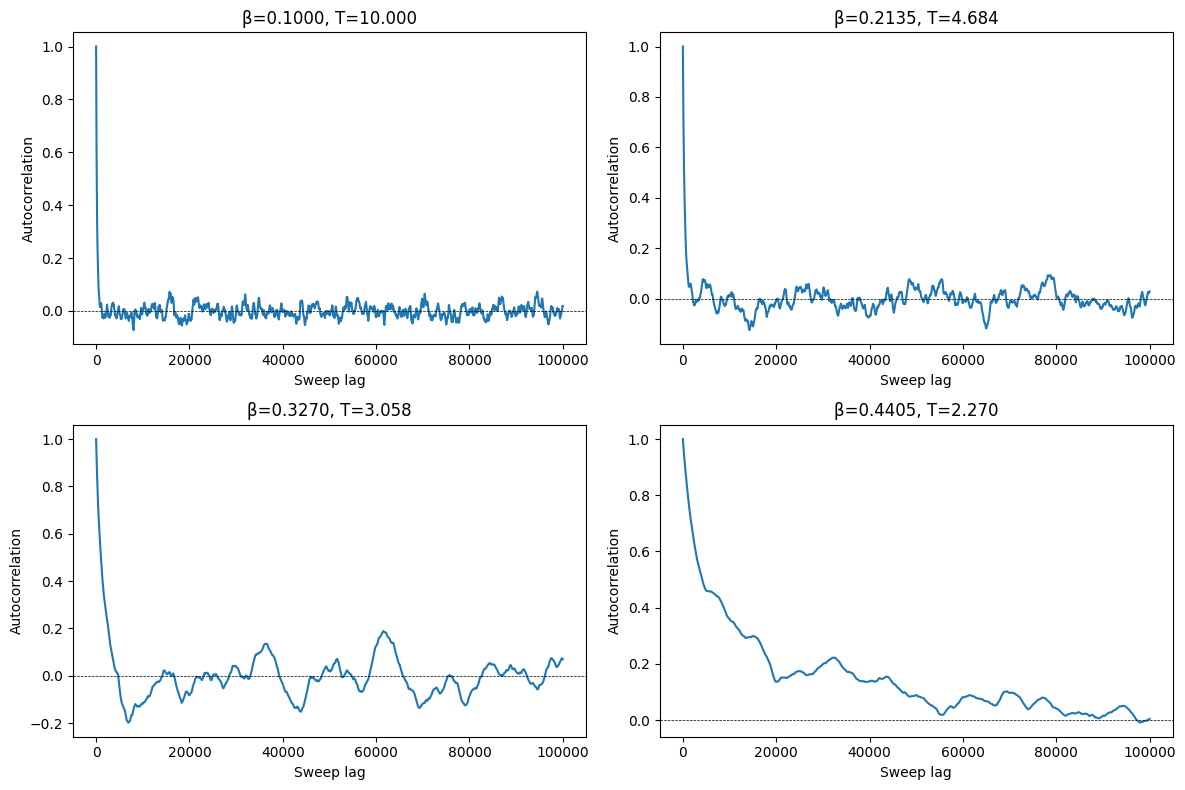

In [58]:
betas_for_mutliple = sorted(set(ising_metrics_moving["beta"][0]))
plot_all_stages(ising_metrics_moving["correlation"][0], betas_for_mutliple)

In [69]:
import pandas as pd

def find_equilibration(stage, window=1000):
    """Returns index where rolling std stabilizes"""
    rolling_std = pd.Series(stage).rolling(window).std().dropna()
    # find first point where std stops decreasing significantly
    diff = np.diff(rolling_std)
    stable_idx = np.argmax(np.abs(diff) < np.percentile(np.abs(diff), 10))
    return stable_idx + window  # offset for rolling window

def plot_all_stages_equlibirium(correlations, betas, energies, eq_fraction=0.1):
    stages = np.array_split(correlations, 4)
    energies_stages = np.array_split(energies, 4)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    for ax, stage, energy_stage, beta in zip(axes.flat, stages, energies_stages, betas):
        # cut equilibration
        eq_cutoff = find_equilibration(stage) #int(len(stage) * eq_fraction)
        print(f"cutoff index: {eq_cutoff}")
        stage_eq  = stage[eq_cutoff:]
        energy_stage_eq = energy_stage[eq_cutoff:]
        print(f"length of stage: {len(stage_eq)}")
        corr = autocorrelation(stage_eq)
        energy_corr = autocorrelation(energy_stage_eq)
        ax.plot(corr[:10000], linestyle='-', color='b', label='Correlation')
        ax.plot(energy_corr[:10000], linestyle='--', color='r', label='Energy')

        ax.legend()
        # ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.set_title(f'β={beta:.4f}, T={1/beta:.3f} | cut={eq_cutoff} sweeps')
        ax.set_xlabel('Sweep lag')
        ax.set_ylabel('Autocorrelation')
    
    plt.tight_layout()
    plt.show()

cutoff index: 1057
length of stage: 248943
cutoff index: 1341
length of stage: 248659
cutoff index: 1397
length of stage: 248603
cutoff index: 1266
length of stage: 248734


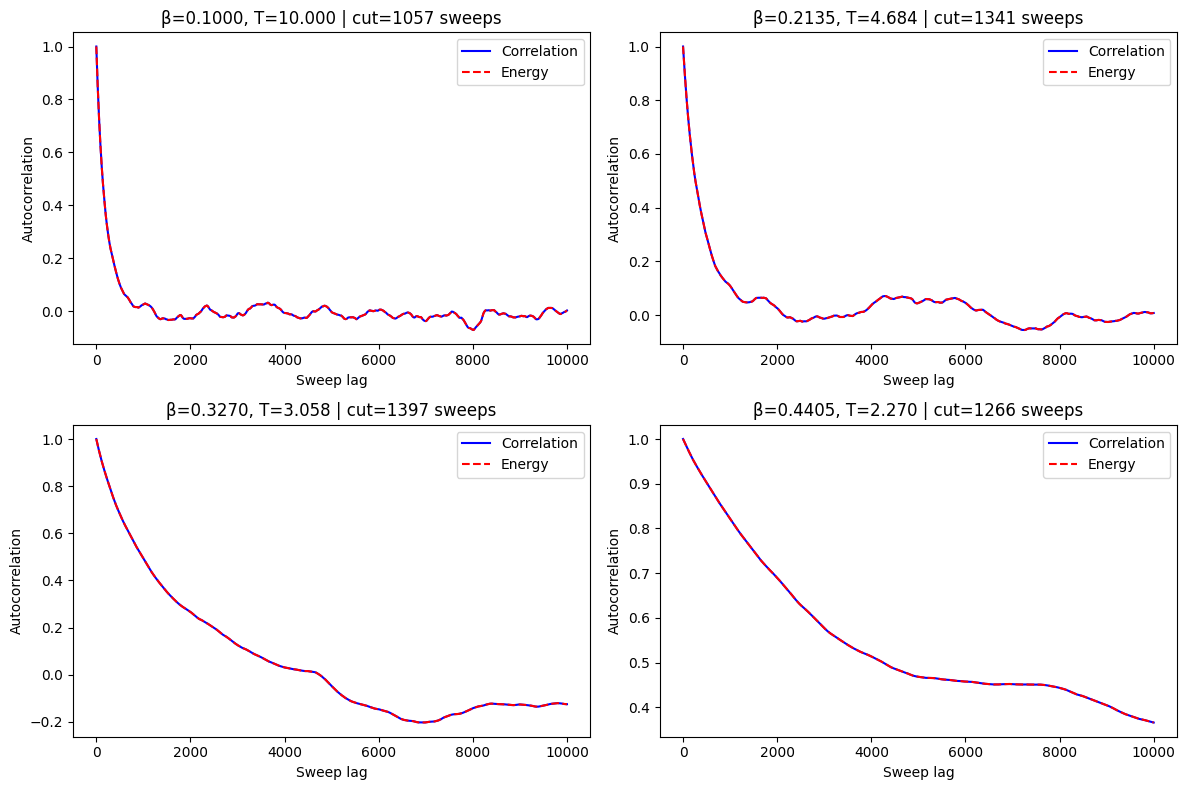

In [70]:
plot_all_stages_equlibirium(ising_metrics_moving["correlation"][0], betas_for_mutliple, ising_metrics_moving["net_energy"][0])